In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [4]:
dataframe = sns.load_dataset('titanic')

In [5]:
dataframe.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
dataframe.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
dataframe = dataframe.drop(columns=['who', 'adult_male','alive', 'deck'] )

In [8]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   embark_town  889 non-null    str     
 10  alone        891 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(4), str(3)
memory usage: 64.6 KB


In [9]:
dataframe['age']= dataframe['age'].fillna(dataframe['age'].mean())
dataframe= dataframe.drop_duplicates()
dataframe= dataframe.dropna()

In [10]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
cols = ['sex', 'embarked', 'embark_town', 'class'] 
for col in cols:
    dataframe[col] = lb.fit_transform(dataframe[col])

In [11]:
dataframe.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,2,2,2,False
1,1,1,0,38.0,1,0,71.2833,0,0,0,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False
4,0,3,1,35.0,0,0,8.0500,2,2,2,True


In [12]:
dataframe = dataframe.astype(int)

<Axes: >

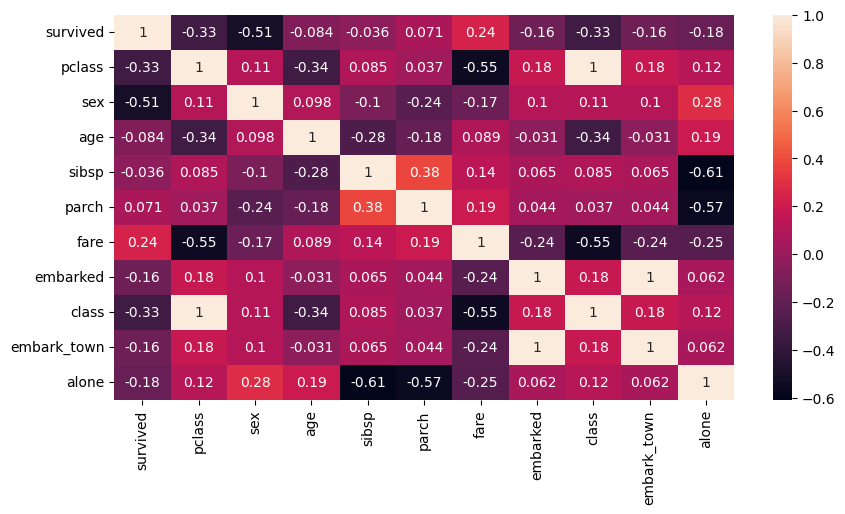

In [13]:
plt.figure(figsize=(10,5))
sns.heatmap(dataframe.corr(numeric_only=True), annot = True)

In [14]:
dataframe.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'embark_town', 'alone'],
      dtype='str')

In [15]:
dataframe.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'embark_town', 'alone'],
      dtype='str')

In [16]:
final = dataframe.drop(columns=['sibsp', 'embark_town', 'fare', 'class' ])

In [17]:
final.columns

Index(['survived', 'pclass', 'sex', 'age', 'parch', 'embarked', 'alone'], dtype='str')

In [18]:
final.head()

,survived,pclass,sex,age,parch,embarked,alone
0,0,3,1,22,0,2,0
1,1,1,0,38,0,0,0
2,1,3,0,26,0,2,1
3,1,1,0,35,0,2,0
4,0,3,1,35,0,2,1


In [19]:
from sklearn.model_selection import train_test_split
y = final['survived']
x = final.drop(columns=['survived'])


x_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
cols = ['age']
scaler = ColumnTransformer(
    transformers=[('num', StandardScaler(), cols)], 
    remainder= 'passthrough' 
)



In [21]:

x_Train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(X_test)

LOGISTIC REGRESSION

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_Train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
y_pred =model.predict(X_test_scaled)
print(y_pred)

[1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 1 0 0 1 1 1 0 0 0 0 0 1 0
 1 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 0 0 1 1 0 1
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 0
 0 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0
 0 1 0 1 1 0 0 0]


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [25]:
accuracy_score(y_test, y_pred)

0.7756410256410257

In [26]:
confusion_matrix(y_test, y_pred)

array([[77, 14],
       [21, 44]])

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.81        91
           1       0.76      0.68      0.72        65

    accuracy                           0.78       156
   macro avg       0.77      0.76      0.77       156
weighted avg       0.77      0.78      0.77       156



KNN

In [28]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= 3)

In [29]:
knn.fit(x_Train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [30]:
knn_pred = knn.predict(X_test_scaled)
print(knn_pred)

[0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0
 1 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1
 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 0 0
 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 1 1 0 0 1 1 0
 0 1 0 1 1 0 0 0]


In [31]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        91
           1       0.77      0.72      0.75        65

    accuracy                           0.79       156
   macro avg       0.79      0.78      0.79       156
weighted avg       0.79      0.79      0.79       156



In [32]:
confusion_matrix(y_test, knn_pred)

array([[77, 14],
       [18, 47]])

Naive Bayes

In [33]:
from sklearn.naive_bayes import GaussianNB
byes = GaussianNB()

In [34]:
byes.fit(x_Train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [35]:
byes_pred = byes.predict(X_test_scaled)
print(byes_pred)

[1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 0 0 0 0 0 1 0
 1 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 1 1 0 1 0 0 0 0 0 1 1 0 1
 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 1 0
 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0
 0 1 0 1 0 0 0 0]


In [36]:
print(classification_report(y_test, byes_pred))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81        91
           1       0.75      0.69      0.72        65

    accuracy                           0.78       156
   macro avg       0.77      0.76      0.77       156
weighted avg       0.77      0.78      0.77       156



In [37]:
print(confusion_matrix(y_test, knn_pred))

[[77 14]
 [18 47]]


DT


In [38]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_Train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [39]:
dt_pred = model_dt.predict(X_test_scaled)

In [40]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81        91
           1       0.77      0.62      0.68        65

    accuracy                           0.76       156
   macro avg       0.76      0.74      0.75       156
weighted avg       0.76      0.76      0.76       156



SVM


In [41]:
from sklearn.svm import SVC
model_svm = SVC(kernel='rbf')


In [42]:
model_svm.fit(x_Train_scaled, y_train)
svm_pred = model_svm.predict(X_test_scaled)

In [43]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.77      0.89      0.83        91
           1       0.80      0.63      0.71        65

    accuracy                           0.78       156
   macro avg       0.79      0.76      0.77       156
weighted avg       0.78      0.78      0.78       156



In [44]:
confusion_matrix(y_test, svm_pred)

array([[81, 10],
       [24, 41]])

Cross Validation


In [45]:
dataframe

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alone
0,0,3,1,22,1,0,7,2,2,2,0
1,1,1,0,38,1,0,71,0,0,0,0
2,1,3,0,26,0,0,7,2,2,2,1
3,1,1,0,35,1,0,53,2,0,2,0
4,0,3,1,35,0,0,8,2,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39,0,5,29,1,2,1,0
887,1,1,0,19,0,0,30,2,0,2,1
888,0,3,0,29,1,2,23,2,2,2,0
889,1,1,1,26,0,0,30,0,0,0,1


In [46]:
dataframe.dtypes

survived       int64
pclass         int64
sex            int64
age            int64
sibsp          int64
parch          int64
fare           int64
embarked       int64
class          int64
embark_town    int64
alone          int64
dtype: object

In [47]:
X_new = dataframe.drop(columns=['survived', 'embarked', 'embark_town', 'sibsp'])
Y_new = dataframe['survived']
colstoscale =  ['age', 'fare']

In [48]:
X_new

,pclass,sex,age,parch,fare,class,alone
0,3,1,22,0,7,2,0
1,1,0,38,0,71,0,0
2,3,0,26,0,7,2,1
3,1,0,35,0,53,0,0
4,3,1,35,0,8,2,1
...,...,...,...,...,...,...,...
885,3,0,39,5,29,2,0
887,1,0,19,0,30,0,1
888,3,0,29,2,23,2,0
889,1,1,26,0,30,0,1


In [49]:
transform_new = ColumnTransformer(
    transformers=[('columns', StandardScaler(), colstoscale)],
    remainder='passthrough'
)

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_new, Y_new, test_size=0.2, random_state=42)

In [51]:
x_train_scaled_new = transform_new.fit_transform(X_train)
X_test_scaled_new = transform_new.transform(X_test)

In [52]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline(
        steps=[
            ('preprocessor', transform_new),
            ('model', model_svm)
        ]
)

In [53]:
from sklearn.model_selection import cross_val_score
score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')

In [54]:
print(score.mean())

0.7701161290322581


In [55]:
score

array([0.76      , 0.768     , 0.74193548, 0.83870968, 0.74193548])

In [56]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('columns', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

In [57]:
test_accuracy = pipeline.score(X_test, y_test)
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Final Test Accuracy: 0.7885


Tryin to boost

In [58]:
from xgboost import XGBClassifier

In [59]:
xgb = XGBClassifier(n_estimators= 100, random_state=42, learning_rate=0.1, max_depth=5, use_label_encoder = False, eval_metric = 'mlogloss')

In [61]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [62]:
XG_pred = xgb.predict(X_test)

In [63]:
print(accuracy_score(y_test, XG_pred))

0.782051282051282


In [64]:
from sklearn.ensemble import GradientBoostingClassifier
gradboost = GradientBoostingClassifier(n_estimators=100, random_state=42, learning_rate=0.1)

In [65]:
gradboost.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [66]:
Grad_pred = xgb.predict(X_test)

In [ ]:
print(accuracy_score(y_test, Grad_pred))

0.782051282051282


In [68]:
confusion_matrix(y_test, XG_pred)

array([[82,  9],
       [25, 40]])

In [69]:
confusion_matrix(y_test, Grad_pred)

array([[82,  9],
       [25, 40]])

In [70]:
print(classification_report(y_test, Grad_pred))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83        91
           1       0.82      0.62      0.70        65

    accuracy                           0.78       156
   macro avg       0.79      0.76      0.77       156
weighted avg       0.79      0.78      0.78       156



In [71]:
print(classification_report(y_test, XG_pred))

              precision    recall  f1-score   support

           0       0.77      0.90      0.83        91
           1       0.82      0.62      0.70        65

    accuracy                           0.78       156
   macro avg       0.79      0.76      0.77       156
weighted avg       0.79      0.78      0.78       156

